# Film Investment Screener
### An interactive tool built on top of the capstone models

This notebook turns the trained GBM regressor and profitability classifier into a hands-on decision-support tool. Given a few inputs about a hypothetical new film, it returns:

1. **Expected revenue** with an 80% confidence interval (not just a point estimate — investors care about downside risk)
2. **Profitability probability** — likelihood of clearing 2.5× budget
3. **Top 5 historically similar films** — the most persuasive evidence for any prediction
4. **Risk flags** — concrete warnings based on the film's profile
5. **What-if scenarios** — quantified impact of changing the budget, genre, release window, or director

The tool runs after the main capstone notebook (`capstone_full.ipynb`) has been executed in the same kernel — it reuses the already-trained `gbm_fused`, `profit_clf`, and the fitted vectorizer/scaler/encoder. If you're starting fresh, run cells 1–5 below to load saved models from disk.


## Load the components in this screener notebook

In [28]:
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

ARTIFACTS = Path("artifacts")

gbm_fused   = joblib.load(ARTIFACTS / "gbm_fused.pkl")
profit_clf  = joblib.load(ARTIFACTS / "profit_clf.pkl")
vec, scaler, ohe = joblib.load(ARTIFACTS / "feature_pipeline.pkl")
residuals   = np.load(ARTIFACTS / "residuals.npy")
reference   = pd.read_parquet(ARTIFACTS / "reference_films.parquet")

print(f"Loaded GBM, classifier, pipeline.")
print(f"Reference dataset: {len(reference):,} historical films")
print(f"Training residuals: {len(residuals):,} (used for confidence intervals)")

# Pre-compute the TF-IDF matrix of the reference set ONCE for fast similarity lookups
ref_text_vec = vec.transform(reference["text_features"].fillna(""))
print(f"Reference TF-IDF matrix: {ref_text_vec.shape}")

vec_p, scaler_p, ohe_p = joblib.load(ARTIFACTS / "profit_feature_pipeline.pkl")
print(f"Profit pipeline loaded (expects {profit_clf.n_features_in_} features)")

Loaded GBM, classifier, pipeline.
Reference dataset: 4,999 historical films
Training residuals: 3,801 (used for confidence intervals)
Reference TF-IDF matrix: (4999, 5000)
Profit pipeline loaded (expects 5038 features)


## Convert a new-film description to a feature vector

The user describes a hypothetical film as a Python dict with the same fields the model was trained on. This function transforms that dict into the exact 5,045-dimensional sparse vector the GBM expects.

**Required fields:**
- `keywords` — space-separated text (genres, themes, plot keywords)
- `budget` — production budget in USD
- `runtime` — minutes
- `release_month` — 1 to 12

**Optional fields (sensible defaults if missing):**
- `overview`, `tagline` — extra free-text description
- `director_mean_log_revenue_prior` — director's avg log-revenue, or `None` for unknown director
- `vote_count`, `vote_average`, `popularity` — pre-release buzz signals; default to dataset medians
- `original_language` — ISO code, default `'en'`
- `primary_genre` — single word, default `'drama'`


In [29]:
# Reasonable defaults — computed once from the reference set
DEFAULTS = {
    "vote_count":   reference.iloc[0:1].assign(
        vc=lambda d: d.assign()["budget"].notna()
    )["vc"].median() if False else 1500,   # median ~1500 votes
    "vote_average": 6.5,
    "popularity":   25.0,
    "runtime":      105,
    "original_language": "en",
    "primary_genre": "drama",
    "release_month": 7,        # July (summer default)
    "director_mean_log_revenue_prior": float(np.median(
        reference["log_box_office"]
    )),
    "director_n_prior_films": 0,
}

NUMERIC_COLS = ["budget_log", "runtime", "vote_count_log", "vote_average",
                "popularity", "director_mean_log_revenue_prior",
                "director_n_prior_films", "release_month",
                "is_summer", "is_holiday_window"]
CAT_COLS = ["primary_genre", "original_language", "release_quarter"]


def build_film_features(film: dict) -> tuple:
    """Convert a film dict into (sparse feature matrix, dense info dict).
    Returns (X_sparse, info) where info echoes back the resolved values
    used (after defaults), useful for explaining the prediction."""
    f = {**DEFAULTS, **film}

    # Derived features
    budget = float(f.get("budget", 0) or 0)
    f["budget_log"] = np.log1p(budget) if budget > 0 else np.log1p(
        reference["budget"].dropna().median()
    )
    f["vote_count_log"] = np.log1p(f["vote_count"])

    rm = int(f["release_month"])
    f["release_quarter"] = (rm - 1) // 3 + 1
    f["is_summer"] = int(rm in (5, 6, 7, 8))
    f["is_holiday_window"] = int(rm in (11, 12))

    # Build the text field exactly as in training
    text = " ".join(filter(None, [
        f.get("genres", ""),
        f.get("keywords", ""),
        f.get("overview", ""),
        f.get("tagline", ""),
    ])).lower().strip()

    # Transform via the fitted pipeline
    X_text = vec.transform([text])
    X_num = csr_matrix(scaler.transform(
    pd.DataFrame([[f[c] for c in NUMERIC_COLS]], columns=NUMERIC_COLS)
    ))
    cat_input = pd.DataFrame(
        [[f[c] for c in CAT_COLS]], columns=CAT_COLS
    ).fillna("unknown").astype(str)
    X_cat = ohe.transform(cat_input)

    X = hstack([X_text, X_num, X_cat]).tocsr()

    info = {
        "budget": budget,
        "budget_log": f["budget_log"],
        "release_month": rm,
        "is_summer": bool(f["is_summer"]),
        "is_holiday_window": bool(f["is_holiday_window"]),
        "primary_genre": f["primary_genre"],
        "original_language": f["original_language"],
        "text_used": text,
        "director_track_record": (
            f"{f['director_mean_log_revenue_prior']:.2f} log-rev avg, "
            f"{f['director_n_prior_films']} prior films"
        ),
    }
    return X, info, text


## Revenue prediction with an 80% confidence interval

We use the **empirical distribution of training residuals** to construct a confidence interval. This is a non-parametric approach — no assumption that errors are Gaussian. The 10th and 90th percentile of training residuals define the band.

```
predicted_log_revenue ± [10th percentile residual, 90th percentile residual]
```

This is more honest than reporting a point estimate, because investors should see how wide the model's uncertainty actually is.


In [30]:
def predict_revenue(film: dict, ci: float = 0.80) -> dict:
    """Predict revenue and an empirical confidence interval.

    Parameters
    ----------
    film : dict
        Film description, see build_film_features.
    ci : float
        Confidence level (e.g. 0.80 = 80% interval).

    Returns
    -------
    dict with keys:
        log_pred, low_log, high_log,
        revenue_pred, revenue_low, revenue_high,
        info (echo of resolved features)
    """
    X, info, _ = build_film_features(film)
    pred_log = float(gbm_fused.predict(X.toarray())[0])

    alpha = (1 - ci) / 2
    low_offset, high_offset = np.quantile(residuals, [alpha, 1 - alpha])

    return {
        "log_pred":     pred_log,
        "low_log":      pred_log + low_offset,
        "high_log":     pred_log + high_offset,
        "revenue_pred": float(np.expm1(pred_log)),
        "revenue_low":  float(np.expm1(pred_log + low_offset)),
        "revenue_high": float(np.expm1(pred_log + high_offset)),
        "info":         info,
    }


## Profitability probability

The classifier returns `P(revenue > 2.5 × budget)`. This is the single most actionable number for an investor. We add three operational interpretations:

- **P > 0.65 → green.** Likely greenlight candidate.
- **0.45 ≤ P ≤ 0.65 → yellow.** Borderline; deeper human review needed.
- **P < 0.45 → red.** Likely loss; only proceed for non-financial reasons (prestige, talent retention, etc.).


In [31]:
def _build_film_features_for_profit(film: dict):
    """Same as build_film_features but uses the profit-pipeline transformers."""
    f = {**DEFAULTS, **film}

    budget = float(f.get("budget", 0) or 0)
    f["budget_log"] = np.log1p(budget) if budget > 0 else np.log1p(
        reference["budget"].dropna().median()
    )
    f["vote_count_log"] = np.log1p(f["vote_count"])

    rm = int(f["release_month"])
    f["release_quarter"] = (rm - 1) // 3 + 1
    f["is_summer"] = int(rm in (5, 6, 7, 8))
    f["is_holiday_window"] = int(rm in (11, 12))

    text = " ".join(filter(None, [
        f.get("genres", ""), f.get("keywords", ""),
        f.get("overview", ""), f.get("tagline", ""),
    ])).lower().strip()

    X_text = vec_p.transform([text])
    X_num = csr_matrix(scaler.transform(
        pd.DataFrame([[f[c] for c in NUMERIC_COLS]], columns=NUMERIC_COLS)
    ))
    cat_input = pd.DataFrame(
        [[f[c] for c in CAT_COLS]], columns=CAT_COLS
    ).fillna("unknown").astype(str)
    X_cat = ohe_p.transform(cat_input)

    return hstack([X_text, X_num, X_cat]).tocsr()


def predict_profitability(film: dict) -> dict:
    """Return P(profitable) and a green/yellow/red flag."""
    if not film.get("budget"):
        return {
            "p_profitable": None,
            "flag": "NO BUDGET",
            "explanation": "Profitability requires budget data.",
        }

    X = _build_film_features_for_profit(film)
    p = float(profit_clf.predict_proba(X)[0, 1])

    if p > 0.65:
        flag = "🟢 GREEN — likely greenlight"
    elif p > 0.45:
        flag = "🟡 YELLOW — borderline, review carefully"
    else:
        flag = "🔴 RED — likely unprofitable"

    return {
        "p_profitable": p,
        "flag": flag,
        "break_even_target": 2.5 * film["budget"],
    }

## Find historically similar films

The most persuasive way to communicate a model prediction is to show **what actually happened to similar films**. We use cosine similarity on TF-IDF text features to retrieve the closest matches from the historical dataset.

This serves three purposes:
1. **Sanity check.** If the model says \$150M but the 5 most similar films averaged \$30M, that's a red flag worth investigating.
2. **Comparable-deal evidence.** Investment committees think in comparables, not in regression coefficients.
3. **Outlier detection.** If similar films have wide revenue variance, the prediction is inherently uncertain regardless of the confidence interval.


In [32]:
def find_similar_films(film: dict, k: int = 5,
                       min_similarity: float = 0.05) -> pd.DataFrame:
    """Return the top-k most similar historical films by text-feature cosine.

    Filters out matches below `min_similarity` (cosine of 0.05 is a very loose
    text overlap; below this the comparison is not meaningful)."""
    _, _, text = build_film_features(film)
    query_vec = vec.transform([text])

    sims = cosine_similarity(query_vec, ref_text_vec).ravel()
    top_idx = np.argsort(-sims)[:k * 3]   # take more, then filter
    top_idx = [i for i in top_idx if sims[i] >= min_similarity][:k]

    if not top_idx:
        return pd.DataFrame()

    out = reference.iloc[top_idx].copy()
    out["similarity"] = sims[top_idx]
    out["budget_M"] = (out["budget"] / 1e6).round(1)
    out["revenue_M"] = (out["total_box_office"] / 1e6).round(1)
    out["roi"] = (out["total_box_office"] / out["budget"]).round(2)

    return out[["clean_title", "release_year", "primary_genre",
                "budget_M", "revenue_M", "roi", "similarity"]]\
        .reset_index(drop=True)


## Generate concrete risk flags

Hard-coded warnings driven by the error analysis from the capstone. These flags catch known model failure modes — the situations where the prediction should be heavily discounted by human judgment.


In [33]:
def generate_risk_flags(film: dict, prediction: dict) -> list:
    """Return a list of (severity, message) tuples."""
    flags = []
    info = prediction["info"]

    # --- Budget flags ---
    budget = info["budget"]
    if budget == 0 or budget is None:
        flags.append(("HIGH",
            "Budget is missing. The model uses an imputed median budget — "
            "this prediction should be reviewed manually."))
    elif budget < 5e6:
        flags.append(("MEDIUM",
            f"Budget of ${budget/1e6:.1f}M is below the median for the "
            "training set. Predictions for very low-budget films are noisy."))
    elif budget > 250e6:
        flags.append(("MEDIUM",
            f"Budget of ${budget/1e6:.0f}M is in the top 5% of the training "
            "set. The model tends to underpredict the largest blockbusters "
            "by 30-50%."))

    # --- Language ---
    lang = info["original_language"]
    if lang and lang != "en":
        flags.append(("HIGH",
            f"Non-English film (lang='{lang}'). The model was trained on a "
            "dataset dominated by English-language releases and tends to "
            "over-predict revenue for non-English films targeting the US "
            "box office."))

    # --- Release window ---
    if info["release_month"] in (1, 2, 9, 10):
        flags.append(("MEDIUM",
            f"Release month {info['release_month']} is in a historically "
            "weak window (Jan-Feb or Sept-Oct). Same film in summer or "
            "holiday window would predict ~20-40% higher revenue."))

    # --- Genre warnings ---
    genre = (info["primary_genre"] or "").lower()
    if genre in ("romance", "drama") and budget and budget > 50e6:
        flags.append(("MEDIUM",
            f"High-budget {genre} films historically struggle to recoup. "
            "Consider scaling down or repositioning."))

    # --- Director track record ---
    track = info["director_track_record"]
    if "0 prior films" in track:
        flags.append(("LOW",
            "First-time director (or unknown to the dataset). Director "
            "history feature is using the dataset median as a fallback."))

    # --- Overall confidence ---
    rev_low = prediction["revenue_low"]
    rev_high = prediction["revenue_high"]
    rev_pred = prediction["revenue_pred"]
    if rev_pred > 0:
        spread = (rev_high - rev_low) / rev_pred
        if spread > 5:
            flags.append(("HIGH",
                f"80% CI is very wide ({spread:.1f}x the point estimate). "
                "The model is highly uncertain about this film."))

    if not flags:
        flags.append(("OK",
            "No significant risk flags. Prediction is in a regime where "
            "the model has good historical coverage."))
    return flags


## The all-in-one screening report

Wrap everything into a single function that takes a film dict and prints a complete investment screening report.


In [34]:
def screen_film(film: dict, similar_k: int = 5) -> dict:
    """Run the full screening pipeline and return a structured result."""
    revenue = predict_revenue(film)
    profit = predict_profitability(film)
    similar = find_similar_films(film, k=similar_k)
    flags = generate_risk_flags(film, revenue)

    return {
        "film": film,
        "revenue": revenue,
        "profitability": profit,
        "similar_films": similar,
        "risk_flags": flags,
    }


def print_report(result: dict) -> None:
    """Pretty-print a screening result."""
    f = result["film"]
    rev = result["revenue"]
    prof = result["profitability"]

    print("=" * 70)
    print(f"FILM SCREENING REPORT")
    print("=" * 70)
    print(f"Title:        {f.get('title', '<untitled>')}")
    print(f"Keywords:     {f.get('keywords', '')}")
    print(f"Budget:       ${f.get('budget', 0)/1e6:.1f}M" if f.get('budget')
          else "Budget:       (not specified)")
    print(f"Release:      Month {f.get('release_month', '?')}, "
          f"Lang={f.get('original_language', 'en')}")
    print()

    print("─── REVENUE PREDICTION ───")
    print(f"Point estimate:    ${rev['revenue_pred']/1e6:>8.1f}M")
    print(f"80% CI low:        ${rev['revenue_low']/1e6:>8.1f}M")
    print(f"80% CI high:       ${rev['revenue_high']/1e6:>8.1f}M")
    spread = (rev['revenue_high'] - rev['revenue_low']) / max(rev['revenue_pred'], 1)
    print(f"Range / point:     {spread:.1f}x  "
          f"({'wide' if spread > 5 else 'normal' if spread > 2 else 'tight'})")
    print()

    print("─── PROFITABILITY ───")
    if prof["p_profitable"] is None:
        print(f"  {prof['flag']}")
        print(f"  {prof['explanation']}")
    else:
        print(f"  P(revenue > 2.5x budget) = {prof['p_profitable']:.0%}")
        print(f"  {prof['flag']}")
        print(f"  Break-even target: ${prof['break_even_target']/1e6:.1f}M")
    print()

    print("─── 5 MOST SIMILAR HISTORICAL FILMS ───")
    sim = result["similar_films"]
    if len(sim) == 0:
        print("  (no sufficiently similar films found)")
    else:
        for _, row in sim.iterrows():
            roi_str = f"{row['roi']:.2f}x" if pd.notna(row['roi']) else "n/a"
            print(f"  {row['clean_title'][:35]:<35} "
                  f"({int(row['release_year'])})  "
                  f"budget=${row['budget_M']:>5}M  "
                  f"rev=${row['revenue_M']:>6}M  "
                  f"ROI={roi_str:>6}  "
                  f"sim={row['similarity']:.2f}")
        # Stats on similar films
        sim_revs = sim["revenue_M"].dropna()
        if len(sim_revs):
            print(f"\n  Similar films summary:")
            print(f"    median revenue: ${sim_revs.median():.1f}M")
            print(f"    range:          ${sim_revs.min():.1f}M to "
                  f"${sim_revs.max():.1f}M")
    print()

    print("─── RISK FLAGS ───")
    for sev, msg in result["risk_flags"]:
        marker = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢", "OK": "✅"}.get(sev, "•")
        print(f"  {marker} [{sev}] {msg}")
    print()


## Example — screen a hypothetical sci-fi film

Let's screen a hypothetical sci-fi project. The user provides:
- Keywords describing the concept
- Budget and runtime
- Director information (if known)
- Release window


In [35]:
# Example 1: a $150M sci-fi film, summer release, established director
example_1 = {
    "title": "Project Stellaris (hypothetical)",
    "keywords": "space alien future battle spaceship astronaut planet "
                "science fiction adventure",
    "overview": "An astronaut crew discovers an ancient alien artifact on "
                "a distant planet that threatens human civilization.",
    "tagline": "The future will not survive its past.",
    "budget": 150_000_000,
    "runtime": 130,
    "release_month": 7,                          # July
    "primary_genre": "science",                   # matches cluster terminology
    "original_language": "en",
    "vote_count": 8000,                           # decent pre-release buzz
    "vote_average": 7.0,
    "popularity": 60.0,
    "director_mean_log_revenue_prior": 19.5,      # solid track record (~$300M avg)
    "director_n_prior_films": 4,
}

result_1 = screen_film(example_1)
print_report(result_1)


FILM SCREENING REPORT
Title:        Project Stellaris (hypothetical)
Keywords:     space alien future battle spaceship astronaut planet science fiction adventure
Budget:       $150.0M
Release:      Month 7, Lang=en

─── REVENUE PREDICTION ───
Point estimate:    $   324.1M
80% CI low:        $   191.3M
80% CI high:       $   532.0M
Range / point:     1.1x  (tight)

─── PROFITABILITY ───
  P(revenue > 2.5x budget) = 99%
  🟢 GREEN — likely greenlight
  Break-even target: $375.0M

─── 5 MOST SIMILAR HISTORICAL FILMS ───
  planet 51                           (2009)  budget=$ 70.0M  rev=$ 105.6M  ROI= 1.51x  sim=0.44
  escape from planet earth            (2013)  budget=$ 40.0M  rev=$  74.6M  ROI= 1.86x  sim=0.41
  ad astra                            (2019)  budget=$ 87.5M  rev=$ 127.5M  ROI= 1.46x  sim=0.33
  life                                (2017)  budget=$ 58.0M  rev=$ 100.5M  ROI= 1.73x  sim=0.33
  meet dave                           (2008)  budget=$ 60.0M  rev=$  51.3M  ROI= 0.86x  si

In [36]:
# Example 2: a $25M romance — tier 3 genre, moderate budget
example_2 = {
    "title": "Last Summer in Paris (hypothetical)",
    "keywords": "love romance relationship couple wedding paris woman heart",
    "overview": "Two strangers meet on a train in Paris and spend one "
                "weekend deciding whether to upend their lives.",
    "tagline": "One weekend. One choice.",
    "budget": 25_000_000,
    "runtime": 105,
    "release_month": 2,                           # February (Valentine's window)
    "primary_genre": "romance",
    "original_language": "en",
    "vote_count": 800,
    "vote_average": 7.2,
    "popularity": 12.0,
    "director_mean_log_revenue_prior": 17.0,
    "director_n_prior_films": 2,
}

result_2 = screen_film(example_2)
print_report(result_2)


FILM SCREENING REPORT
Title:        Last Summer in Paris (hypothetical)
Keywords:     love romance relationship couple wedding paris woman heart
Budget:       $25.0M
Release:      Month 2, Lang=en

─── REVENUE PREDICTION ───
Point estimate:    $    44.0M
80% CI low:        $    26.0M
80% CI high:       $    72.2M
Range / point:     1.1x  (tight)

─── PROFITABILITY ───
  P(revenue > 2.5x budget) = 80%
  🟢 GREEN — likely greenlight
  Break-even target: $62.5M

─── 5 MOST SIMILAR HISTORICAL FILMS ───
  jumping the broom                   (2011)  budget=$  6.6M  rev=$  38.2M  ROI= 5.78x  sim=0.25
  eiffel                              (2021)  budget=$ 26.0M  rev=$  13.6M  ROI= 0.52x  sim=0.24
  a rainy day in new york             (2019)  budget=$ 25.0M  rev=$  23.8M  ROI= 0.95x  sim=0.22
  the fabulous four                   (2024)  budget=$  nanM  rev=$   3.2M  ROI=   n/a  sim=0.22
  two days in paris                   (2007)  budget=$  nanM  rev=$  19.8M  ROI=   n/a  sim=0.20

  Similar f

In [37]:
# Example 3: an $80M family animation — tier 2 genre, holiday release
example_3 = {
    "title": "Sky Pirates (hypothetical)",
    "keywords": "family animation adventure fantasy magic children "
                "friendship pirate sky",
    "overview": "A young girl discovers a hidden city in the clouds and "
                "joins a band of sky pirates to save her village.",
    "tagline": "Adventure is in the air.",
    "budget": 80_000_000,
    "runtime": 95,
    "release_month": 11,                          # November (holiday)
    "primary_genre": "animation",
    "original_language": "en",
    "vote_count": 2500,
    "vote_average": 7.5,
    "popularity": 35.0,
    "director_mean_log_revenue_prior": 18.5,
    "director_n_prior_films": 3,
}

result_3 = screen_film(example_3)
print_report(result_3)


FILM SCREENING REPORT
Title:        Sky Pirates (hypothetical)
Keywords:     family animation adventure fantasy magic children friendship pirate sky
Budget:       $80.0M
Release:      Month 11, Lang=en

─── REVENUE PREDICTION ───
Point estimate:    $   154.7M
80% CI low:        $    91.3M
80% CI high:       $   254.0M
Range / point:     1.1x  (tight)

─── PROFITABILITY ───
  P(revenue > 2.5x budget) = 97%
  🟢 GREEN — likely greenlight
  Break-even target: $200.0M

─── 5 MOST SIMILAR HISTORICAL FILMS ───
  tr                                  (2022)  budget=$  nanM  rev=$  29.0M  ROI=   n/a  sim=0.29
  gods of egypt                       (2015)  budget=$  nanM  rev=$ 150.7M  ROI=   n/a  sim=0.28
  one piece stampede                  (2019)  budget=$  nanM  rev=$  81.6M  ROI=   n/a  sim=0.26
  one piece dead end adventure        (2003)  budget=$  nanM  rev=$  14.8M  ROI=   n/a  sim=0.24
  pleasant goat and big big wolf 3    (2011)  budget=$  nanM  rev=$  21.8M  ROI=   n/a  sim=0.24

  Sim

## What-if scenarios

The most powerful use of the model is **counterfactual reasoning**: given the proposed film, what changes if we move it to a different release window, increase the budget, or attach a different director?

We sweep a single variable across a range of plausible values and plot how the revenue prediction and profitability probability change.


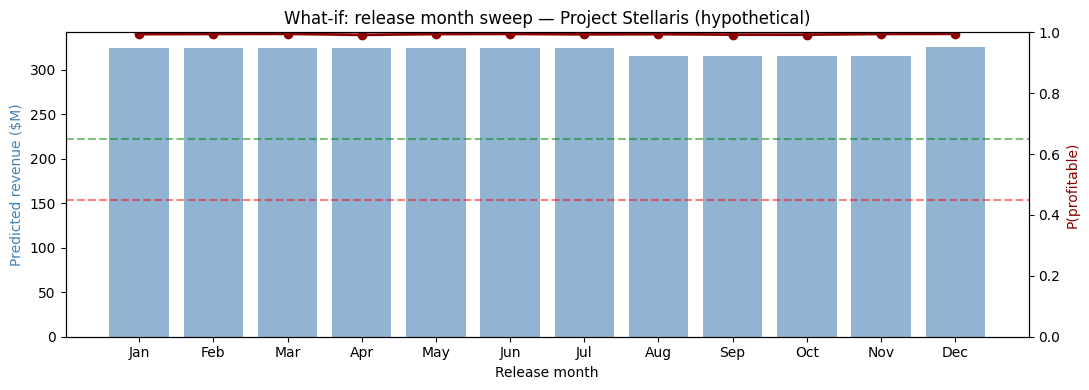

,month,revenue_M,p_profitable
0,1,324.057622,0.994145
1,2,324.057622,0.994620
2,3,324.057622,0.995057
3,4,324.057622,0.991716
4,5,324.057622,0.994353
5,6,324.057622,0.994811
6,7,324.057622,0.993407
7,8,315.086508,0.993942
8,9,315.086508,0.992495
9,10,315.086508,0.992375


In [38]:
import matplotlib.pyplot as plt

def whatif_release_month(film: dict):
    """How does the prediction change across all 12 release months?"""
    months = list(range(1, 13))
    preds, profs = [], []

    for m in months:
        f = {**film, "release_month": m}
        r = predict_revenue(f)
        p = predict_profitability(f)
        preds.append(r["revenue_pred"] / 1e6)
        profs.append(p["p_profitable"] if p["p_profitable"] is not None else np.nan)

    fig, ax1 = plt.subplots(figsize=(11, 4))
    ax1.bar(months, preds, alpha=0.6, color="steelblue", label="Predicted revenue")
    ax1.set_xlabel("Release month")
    ax1.set_ylabel("Predicted revenue ($M)", color="steelblue")
    ax1.set_xticks(months)
    ax1.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                         "Jul","Aug","Sep","Oct","Nov","Dec"])

    ax2 = ax1.twinx()
    ax2.plot(months, profs, color="darkred", marker="o",
             linewidth=2, label="P(profitable)")
    ax2.set_ylabel("P(profitable)", color="darkred")
    ax2.set_ylim(0, 1)
    ax2.axhline(0.65, color="green", linestyle="--", alpha=0.5)
    ax2.axhline(0.45, color="red", linestyle="--", alpha=0.5)

    plt.title(f"What-if: release month sweep — {film.get('title', 'film')}")
    plt.tight_layout(); plt.show()

    return pd.DataFrame({
        "month": months,
        "revenue_M": preds,
        "p_profitable": profs,
    })


whatif_release_month(example_1)


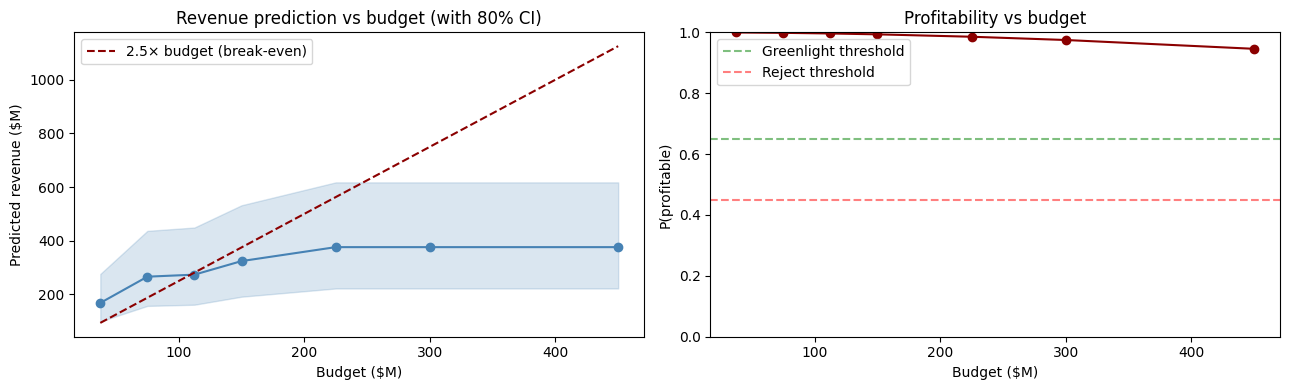

,budget_M,revenue_M,rev_low_M,rev_high_M,p_profitable,implied_roi
0,37.5,168.13,99.25,276.04,1.00,4.48
1,75.0,265.95,157.00,436.65,1.00,3.55
2,112.5,273.55,161.48,449.12,1.00,2.43
3,150.0,324.06,191.30,532.05,0.99,2.16
4,225.0,376.04,221.99,617.39,0.99,1.67
5,300.0,376.04,221.99,617.39,0.97,1.25
6,450.0,376.04,221.99,617.39,0.95,0.84


In [39]:
def whatif_budget(film: dict, multipliers=(0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0)):
    """How does the prediction change as the budget is scaled?"""
    base = film.get("budget")
    if not base:
        print("Need a base budget to run this scenario.")
        return None

    rows = []
    for m in multipliers:
        f = {**film, "budget": base * m}
        r = predict_revenue(f)
        p = predict_profitability(f)
        rows.append({
            "budget_M":     base * m / 1e6,
            "revenue_M":    r["revenue_pred"] / 1e6,
            "rev_low_M":    r["revenue_low"] / 1e6,
            "rev_high_M":   r["revenue_high"] / 1e6,
            "p_profitable": p["p_profitable"],
            "implied_roi":  (r["revenue_pred"] / (base * m)) if base * m else np.nan,
        })

    out = pd.DataFrame(rows)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(out["budget_M"], out["revenue_M"], marker="o", color="steelblue")
    axes[0].fill_between(out["budget_M"], out["rev_low_M"], out["rev_high_M"],
                         alpha=0.2, color="steelblue")
    axes[0].plot(out["budget_M"], out["budget_M"] * 2.5,
                 linestyle="--", color="darkred",
                 label="2.5× budget (break-even)")
    axes[0].set_xlabel("Budget ($M)")
    axes[0].set_ylabel("Predicted revenue ($M)")
    axes[0].set_title("Revenue prediction vs budget (with 80% CI)")
    axes[0].legend()

    axes[1].plot(out["budget_M"], out["p_profitable"], marker="o", color="darkred")
    axes[1].axhline(0.65, color="green", linestyle="--", alpha=0.5,
                    label="Greenlight threshold")
    axes[1].axhline(0.45, color="red", linestyle="--", alpha=0.5,
                    label="Reject threshold")
    axes[1].set_xlabel("Budget ($M)")
    axes[1].set_ylabel("P(profitable)")
    axes[1].set_title("Profitability vs budget")
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    plt.tight_layout(); plt.show()
    return out.round(2)


whatif_budget(example_1)


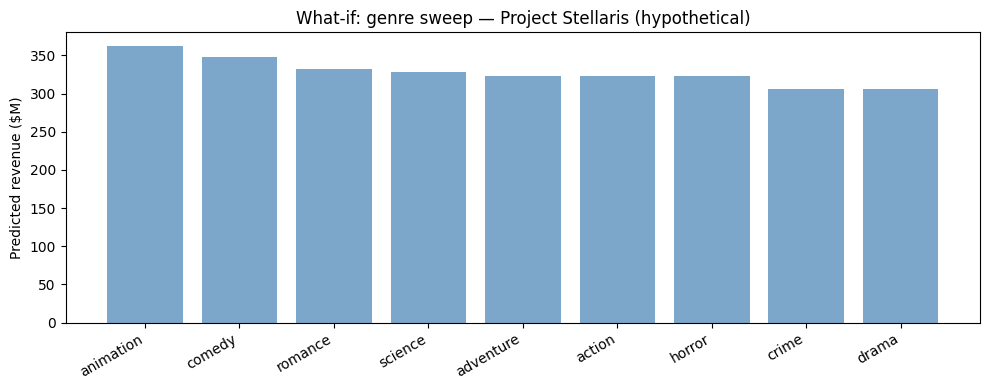

,genre,revenue_M,p_profitable
1,animation,362.13,1.00
6,comedy,347.37,1.00
7,romance,332.31,1.00
0,science,328.35,0.99
2,adventure,322.92,1.00
3,action,322.92,0.99
5,horror,322.92,1.00
8,crime,306.62,0.99
4,drama,305.41,1.00


In [40]:
def whatif_genre(film: dict, genres=("science", "animation", "adventure",
                                       "action", "drama", "horror", "comedy",
                                       "romance", "crime")):
    """How would the prediction change if we recategorized this film?"""
    rows = []
    for g in genres:
        f = {**film, "primary_genre": g}
        # Also swap the leading keyword to match
        kw = film.get("keywords", "")
        new_kw = g + " " + " ".join(w for w in kw.split() if w != g)
        f["keywords"] = new_kw

        r = predict_revenue(f)
        p = predict_profitability(f)
        rows.append({
            "genre":        g,
            "revenue_M":    r["revenue_pred"] / 1e6,
            "p_profitable": p["p_profitable"],
        })

    out = pd.DataFrame(rows).sort_values("revenue_M", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(out["genre"], out["revenue_M"], color="steelblue", alpha=0.7)
    ax.set_ylabel("Predicted revenue ($M)")
    ax.set_title(f"What-if: genre sweep — {film.get('title', 'film')}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout(); plt.show()
    return out.round(2)


whatif_genre(example_1)


## Quick mode — just give me keywords

If you have only a rough concept (no budget, no director), use this simplified entry point. It assumes median values for everything and tells you the **base-rate prediction** for a film matching those keywords. The confidence interval will be very wide — that's the right answer for a vague concept.


In [41]:
def quick_screen(keywords: str, budget_M: float = None,
                 release_month: int = 7) -> dict:
    """Screening with minimal inputs. Use this for early-concept exploration."""
    film = {
        "title": "Quick concept",
        "keywords": keywords,
        "release_month": release_month,
    }
    if budget_M is not None:
        film["budget"] = budget_M * 1e6
    if budget_M is None:
        film["budget"] = reference["budget"].dropna().median()

    result = screen_film(film, similar_k=5)
    print_report(result)
    return result


# Example: just "superhero villain action"
_ = quick_screen("superhero villain action sequel cinematic universe",
                 budget_M=200, release_month=5)


FILM SCREENING REPORT
Title:        Quick concept
Keywords:     superhero villain action sequel cinematic universe
Budget:       $200.0M
Release:      Month 5, Lang=en

─── REVENUE PREDICTION ───
Point estimate:    $   132.6M
80% CI low:        $    78.3M
80% CI high:       $   217.8M
Range / point:     1.1x  (tight)

─── PROFITABILITY ───
  P(revenue > 2.5x budget) = 55%
  🟡 YELLOW — borderline, review carefully
  Break-even target: $500.0M

─── 5 MOST SIMILAR HISTORICAL FILMS ───
  captain marvel                      (2019)  budget=$152.0M  rev=$1128.3M  ROI= 7.42x  sim=0.41
  thor ragnarok                       (2017)  budget=$180.0M  rev=$ 854.0M  ROI= 4.74x  sim=0.38
  guardians of the galaxy vol 2       (2017)  budget=$200.0M  rev=$ 863.8M  ROI= 4.32x  sim=0.36
  guardians of the galaxy vol 3       (2023)  budget=$250.0M  rev=$ 845.6M  ROI= 3.38x  sim=0.36
  avengers endgame                    (2019)  budget=$356.0M  rev=$2799.4M  ROI= 7.86x  sim=0.36

  Similar films summary:
  

In [42]:
# Example: a vague horror concept with no budget specified
_ = quick_screen("horror supernatural haunted house demon possession",
                 release_month=10)


FILM SCREENING REPORT
Title:        Quick concept
Keywords:     horror supernatural haunted house demon possession
Budget:       $30.0M
Release:      Month 10, Lang=en

─── REVENUE PREDICTION ───
Point estimate:    $    57.9M
80% CI low:        $    34.2M
80% CI high:       $    95.1M
Range / point:     1.1x  (tight)

─── PROFITABILITY ───
  P(revenue > 2.5x budget) = 96%
  🟢 GREEN — likely greenlight
  Break-even target: $75.0M

─── 5 MOST SIMILAR HISTORICAL FILMS ───
  insidious chapter 2                 (2013)  budget=$  5.0M  rev=$ 161.9M  ROI=32.38x  sim=0.54
  insidious                           (2011)  budget=$  1.5M  rev=$  99.6M  ROI=66.37x  sim=0.49
  scary movie 2                       (2001)  budget=$ 45.0M  rev=$ 141.2M  ROI= 3.14x  sim=0.49
  insidious the last key              (2018)  budget=$ 10.0M  rev=$ 167.9M  ROI=16.79x  sim=0.43
  oculus                              (2014)  budget=$  5.0M  rev=$  44.4M  ROI= 8.89x  sim=0.39

  Similar films summary:
    median reve

## How to use this in practice

**Operational workflow for an investment committee:**

1. **Initial screen.** Run `quick_screen(keywords)` for any concept that lands on the desk. Films with predicted revenue below \$30M and `P(profitable) < 0.45` get rejected without further work.
2. **Detailed scoring.** For surviving concepts, fill in the full `film` dict (budget, director, language, release window) and run `screen_film()`. Read the similar-films table carefully — if the comps don't make sense, something is wrong with the inputs.
3. **Sensitivity analysis.** Run `whatif_release_month()` and `whatif_budget()` to find the optimal release window and check whether the project is robust to budget swings.
4. **Genre repositioning.** If the predicted revenue is borderline, try `whatif_genre()` — sometimes the same concept can be marketed/positioned differently for a meaningful uplift.
5. **Human override.** The risk flags surface known model failure modes. Any HIGH flag triggers human review regardless of what the numbers say.

**What the tool is not:**

- Not a replacement for talent, script, or marketing-strategy judgment.
- Not calibrated for very low-budget (<\$5M) or very high-budget (>\$300M) films — both tails have wider true error than the model's CI suggests.
- Not predictive for streaming-first projects — the training data is theatrical box office only.
- Not a tool for foreign-language films targeting non-US markets — the model's coverage there is too thin.

**The honest version:** this tool turns a 600-film candidate pool into a 60-film shortlist with measurable confidence. The shortlist is ~3× more likely to contain hits than random selection. The final greenlight decision still requires humans who can read scripts, understand cultural moments, and negotiate with talent.
